In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [13]:
logs = pd.read_csv('../results/log_hybrid-e10.txt')
logs.columns

Index(['episodes', 'explored_states', 'score'], dtype='str')

In [14]:
def smoove(x,y, window_size=25):
    if window_size*2 > x.shape[0]:
        return x,y

    ones = np.ones(window_size) / window_size
    new_y = np.convolve(y, ones, mode='valid')
    return x[-new_y.shape[0]:], new_y

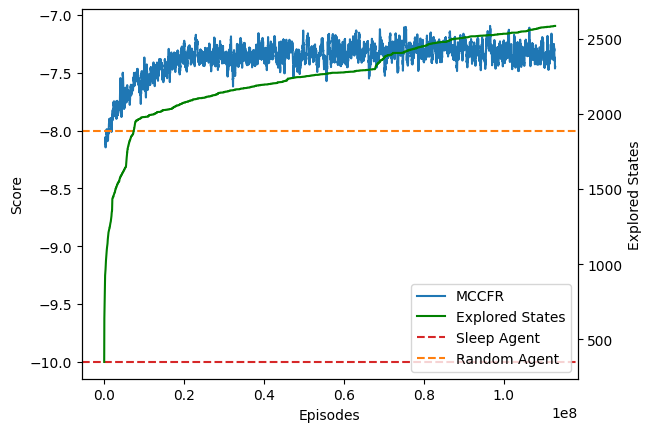

In [16]:
fig,ax = plt.subplots()

x,y = smoove(logs['episodes'], logs['score'])

ln0 = ax.plot(x, y, label='MCCFR')
ax.set_ylabel('Score')
ax.set_xlabel('Episodes')

# For 30-step games
#ln2 = [ax.axhline(y=-218, color='C3', linestyle='--', label='Sleep Agent')]
#ln3 = [ax.axhline(y=-154, color='C1', linestyle='--', label='Random Agent')]
#ln4 = [ax.axhline(y=-58, color='C5', linestyle='--', label='Heuristic Agent')]
#ln5 = [ax.axhline(y=-8.75, color='C4', linestyle='--', label='RL Agent')]

# For 10-step games
ln2 = [ax.axhline(y=-10, color='C3', linestyle='--', label='Sleep Agent')]
ln3 = [ax.axhline(y=-8, color='C1', linestyle='--', label='Random Agent')]

ax2 = ax.twinx()
ax2.set_ylabel('Explored States')
ln1 = ax2.plot(logs['episodes'], logs['explored_states'], color='green', label='Explored States')

#lns = ln0+ln1+ln2+ln3+ln4+ln5
lns = ln0+ln1+ln2+ln3

labs = [l.get_label() for l in lns]
ax2.legend(lns,labs, loc='lower right')

plt.show()